In [1]:
import sys
from pathlib import Path
import torch
import numpy as np
from time import time
from matplotlib import pyplot as plt

#import os # Debugging for cpu-only context
#os.environ["CUDA_VISIBLE_DEVICES"] = ""
#torch.cuda.is_available = lambda : False # Force CPU-only context for testing and compatibility

# Note: Will need to move HeFESTo_functions.py to nMELTS/utils so it will be ported properly. 

# Handle both notebook and script contexts
try:
    repo_root = Path(__file__).parent.parent
except NameError:
    # Running in Jupyter notebook context
    repo_root = Path.cwd().parent

# Add both src and src/nMELTS to path
src_root = repo_root / "src"
module_root = src_root / "module"

if str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))
if str(module_root) not in sys.path:
    sys.path.insert(0, str(module_root))

# Import utilities and API
from ngibbs.utils.math_utils import grid_sample, grid_sample_explicit, mix_compositions, IDX_2D_Lithosphere
from ngibbs.engine.API import HeFESToMarsEmulatorCPU, HeFESToEmulatorCPU
from ngibbs.config.constants import HEFESTO_ABBREVIATION_TO_SHORT_NAMES
REV_HEFESTO_ABBREVIATION_TO_SHORT_NAMES = {v: k for k, v in HEFESTO_ABBREVIATION_TO_SHORT_NAMES.items()}


if torch.cuda.is_available():
    from ngibbs.engine.API import HeFESToMarsEmulatorGPU, HeFESToEmulatorGPU # Optional GPU emulator, only imported if CUDA is available

# Check emulator availability
if HeFESToEmulatorCPU is None:
    print("\nNote: Pre-instantiated emulators not available (model files missing).")
    print("Create HeFESToAPI instances with valid model paths when needed.")
else:
    print("\nEmulators available:")
    print(f"  - HeFESToEmulatorCPU")
    if torch.cuda.is_available():
        print(f"  - HeFESToEmulatorGPU")


Emulators available:
  - HeFESToEmulatorCPU
  - HeFESToEmulatorGPU


In [2]:
# MELTS PS Phase Diagram Demo - ptt and nGibbs

import sys
from pathlib import Path
import numpy as np
import pandas as pd

# Get repo root (from cell 1 setup)
try:
    repo_root = Path(__file__).parent.parent
except NameError:
    repo_root = Path.cwd().parent

# Add builder path for HeFESTo functions
builder_root = repo_root / "src" / "builder"
sys.path.insert(0, str(builder_root))

from HeFESTo.HeFESTo_functions import extract_bulk_properties_from_simulation_dir, load_fort99_componentMoles 

# Define compositions for reference
compositions = {
    'harzburgite_PS': {
    'Si': 3.57887,
    'Mg': 5.64233,
    'Fe': 0.58052,
    'Ca': 0.07969,
    'Al': 0.09740,
    'Na': 0.00160,
    'Cr': 0.01960,
    'O': 13.63947
    },

    'DMM_PS': {
    'Si': 3.79222,
    'Mg': 4.88475,
    'Fe': 0.57874,
    'Ca': 0.28734,
    'Al': 0.39685,
    'Na': 0.02197,
    'Cr': 0.03813,
    'O': 14.00450
    },

    "basalt_PS": {
    'Si': 4.61116,
    'Mg': 1.33197,
    'Fe': 0.61701,
    'Ca': 1.22855,
    'Al': 1.81090,
    'Na': 0.39533,
    'Cr': 0.00508,
    'O': 15.35841
    }
}

# Load HeFESTo PS simulations - use absolute paths
hefesto_workspace = repo_root / "notebooks" / "demoHeFESToData"

sim_paths = {
    'harzburgite_PS': hefesto_workspace / 'htz_PS',
    'DMM_PS': hefesto_workspace / 'DMM_PS',
    'basalt_PS': hefesto_workspace / 'basalt_PS'
}

# Dictionary to store DataFrames
sim_tables = {}
comp_tables = {}
mass_tables = {}
indexer = HeFESToEmulatorCPU.isentropic_emulator.ml_indexer # Object used to manipulate emulator inputs and outputs

print("Loading HeFESTo simulations...\n")

for sim_name, sim_path in sim_paths.items():
    try:
        print(f"Loading {sim_name} from {sim_path}...")
        props = extract_bulk_properties_from_simulation_dir(str(sim_path))
        comp_tables[sim_name] = load_fort99_componentMoles(str(sim_path), indexer)
        # convert component moles (B, C) to phase masses (B, P)
        _, mass_tables[sim_name] = HeFESToEmulatorCPU.isentropic_emulator.make_phase_tables(torch.tensor(comp_tables[sim_name], dtype=torch.float32))


        # Build each table section explicitly so no columns get lost in a dict update.
        n_rows = len(props['T(K)'])
        base_df = pd.DataFrame({
            'T(K)': np.asarray(props['T(K)']).reshape(n_rows),
            'P(GPa)': np.asarray(props['P(GPa)']).reshape(n_rows),
            'VS(km/s)': np.asarray(props['VS(km/s)']).reshape(n_rows),
            'VP(km/s)': np.asarray(props['VP(km/s)']).reshape(n_rows),
            'rho(g/cm^3)': np.asarray(props['rho(g/cm^3)']).reshape(n_rows),
            'VB(km/s)': np.asarray(props['VB(km/s)']).reshape(n_rows),
            'VSQ(km/s)': np.asarray(props['VSQ(km/s)']).reshape(n_rows),
            'VPQ(km/s)': np.asarray(props['VPQ(km/s)']).reshape(n_rows),
            'H(kJ/g)': np.asarray(props['H(kJ/g)']).reshape(n_rows),
            'S(J/g/K)': np.asarray(props['S(J/g/K)']).reshape(n_rows),
            'alpha(1e5_K^-1)': np.asarray(props['alpha(1e5_K^-1)']).reshape(n_rows),
            'cp(J/g/K)': np.asarray(props['cp(J/g/K)']).reshape(n_rows),
            'KS(GPa)': np.asarray(props['KS(GPa)']).reshape(n_rows),
        })

        component_df = pd.DataFrame(index=base_df.index)
        for i, comp_name in enumerate(props['component_names']):
            component_df[f'comp_{comp_name}'] = np.asarray(props['component_moles'][:, i]).reshape(n_rows)

        df = pd.concat([base_df, component_df], axis=1) #bulk_df,
        sim_tables[sim_name] = df

        print(f"  -> Loaded {len(df)} rows")
        print(f"  -> Columns: {list(df.columns)[:8]}...")
        print()

    except Exception as e:
        print(f"ERROR loading {sim_name}: {e}\n")

# Display summary
print("="*70)
print("SUMMARY OF LOADED SIMULATIONS")
print("="*70)

emulated_components = {}
emulated_mass_tables = {}

emulated_components_NN = {}
emulated_mass_tables_NN = {}

for sim_name, df in sim_tables.items():
    

    comp = compositions[sim_name]
    headers = []
    print(f"\n{sim_name} composition: {comp}")
    comp_array = np.zeros((1, len(comp)), dtype=np.float32)
    for idx, (element, value) in enumerate(comp.items()):
        headers.append(element)
        comp_array[0, idx] = value
        
    input_grid = np.concatenate([sim_tables[sim_name][['P(GPa)', 'S(J/g/K)']].to_numpy(), np.tile(comp_array, (sim_tables[sim_name].shape[0], 1))], axis=1)
    print(f"Input grid shape: {input_grid.shape}")

    headers = ['P(GPa)(System_main)', 'S(J/g/K)(System_main)', ] + headers
    #features_tensor = HeFESToEmulatorCPU.parse_input(input_grid, headers=headers)
    output = HeFESToEmulatorCPU.ForwardMB(
        input_grid,
        headers=headers,
        outputs=['component_moles', 'phase_tables']
    )

    emulated_components[sim_name], (_, emulated_mass_tables[sim_name]) = output['component_moles'], output['phase_tables']

    print(f"\n{sim_name}:")
    print(f"  Shape: {df.shape}")
    print(f"  P range: {df['P(GPa)'].min():.2f} - {df['P(GPa)'].max():.2f} GPa")
    print(f"  T range: {df['T(K)'].min():.0f} - {df['T(K)'].max():.0f} K")
    print(f"  Description:\n{df.describe().to_string()}")

Loading HeFESTo simulations...

Loading harzburgite_PS from c:\Git_Repositories\nGibbs\notebooks\demoHeFESToData\htz_PS...
  -> Loaded 4089 rows
  -> Columns: ['T(K)', 'P(GPa)', 'VS(km/s)', 'VP(km/s)', 'rho(g/cm^3)', 'VB(km/s)', 'VSQ(km/s)', 'VPQ(km/s)']...

Loading DMM_PS from c:\Git_Repositories\nGibbs\notebooks\demoHeFESToData\DMM_PS...
  -> Loaded 4089 rows
  -> Columns: ['T(K)', 'P(GPa)', 'VS(km/s)', 'VP(km/s)', 'rho(g/cm^3)', 'VB(km/s)', 'VSQ(km/s)', 'VPQ(km/s)']...

Loading basalt_PS from c:\Git_Repositories\nGibbs\notebooks\demoHeFESToData\basalt_PS...
  -> Loaded 34 rows
  -> Columns: ['T(K)', 'P(GPa)', 'VS(km/s)', 'VP(km/s)', 'rho(g/cm^3)', 'VB(km/s)', 'VSQ(km/s)', 'VPQ(km/s)']...

SUMMARY OF LOADED SIMULATIONS

harzburgite_PS composition: {'Si': 3.57887, 'Mg': 5.64233, 'Fe': 0.58052, 'Ca': 0.07969, 'Al': 0.0974, 'Na': 0.0016, 'Cr': 0.0196, 'O': 13.63947}
Input grid shape: (4089, 10)

harzburgite_PS:
  Shape: (4089, 85)
  P range: 0.00 - 140.00 GPa
  T range: 1217 - 3635 K
  

In [4]:

# Phase stack animation: ground truth vs emulated, cycling through isentropes in
# ascending entropy order.  Requires cells 1 and 2 (sim_tables, mass_tables,
# emulated_mass_tables, phase_order helpers).

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
from src.ngibbs.config.constants import HEFESTO_ABBREVIATION_TO_SHORT_NAMES

# --- Select composition ---
sim_name = 'DMM_PS'   # options:'DMM_PS', 'harzburgite_PS' # Or: Do your own PS grid calculation in HeFESTo! You'll need to input the chemistry in the dictionaries above, The above block doesn't read input composition.

INDEX_TO_PHASE = {
    1:'plg', 2:'sp', 3:'opx', 4:'c2c', 5:'cpx', 6:'wo', 7:'pwo', 8:'gt', 9:'cpv',
    10:'ol', 11:'wa', 12:'ri', 13:'il', 14:'pv', 15:'ppv', 16:'cf', 17:'nal', 18:'mw',
    19:'qtz', 20:'coes', 21:'st', 22:'apbo', 23:'ky', 24:'neph', 25:'fea', 26:'feg', 27:'fee'
}

PHASE_TO_INDEX = {v: k for k, v in INDEX_TO_PHASE.items()}

phase_names = HeFESToEmulatorCPU.isentropic_emulator.ml_indexer.all_phases
mass_phasedict = HeFESToEmulatorCPU.isentropic_emulator.ml_indexer.mass_phasedict


IP_PYROLITE = [19,20,21,22,10,11,12,18,14,15,13,8,16,9,3,4,5,1,2,23,24,17,25,26,27,6,7] # Convention of HeFESTo creators. Table comp names

phase_order = []

for i, idx in enumerate(IP_PYROLITE):
    #print(f"{i}: {INDEX_TO_PHASE[idx]}")
    shortname = INDEX_TO_PHASE[idx]
    if shortname in HEFESTO_ABBREVIATION_TO_SHORT_NAMES.values():
        phase_order.append(np.array(list(HEFESTO_ABBREVIATION_TO_SHORT_NAMES.keys()))[np.array(list(HEFESTO_ABBREVIATION_TO_SHORT_NAMES.values())) == shortname][0])

# Now stack phase abundances in this order (bottom to top) using the following script! Use the matplotlib.animation.FuncAnimation function to animate  

# -------------------------------------------------------
# Phase color rules (named colors, grouped by mineral family)
# -------------------------------------------------------
def phase_colors():
    col = {}

    # Silica polymorphs
    for p in ['qtz', 'coes', 'st', 'apbo', 'cacl']:
        col[p] = 'dimgray'

    # Plagioclase / feldspars (light)
    for p in ['plg', 'pwo', 'wo', 'neph']:
        col[p] = 'lightgray'

    # Aluminum silicates & Al-bearing (distinct from general silica)
    for p in ['ky', 'nal']:
        col[p] = 'mediumpurple'

    # Pyroxenes
    for p in ['opx', 'cpx', 'c2c']:
        col[p] = 'steelblue'

    # Spinel
    col['sp'] = 'brown'

    # Garnet
    col['gt'] = 'red'

    # Olivine + high-P polymorphs
    for p in ['ol', 'wa', 'ri', 'il']:
        col[p] = 'forestgreen'

    # Perovskite family (varying yellow/beige)
    col['pv']  = 'khaki'
    col['ppv'] = 'goldenrod'
    col['cf']  = 'wheat'
    col['cpv'] = 'tan'

    # Iron phases (native iron/allotropes)
    for p in ['fea', 'feg', 'fee']:
        col[p] = 'sienna'

    # Ferropericlase / magnesiowüstite (if present)
    col['mw'] = 'magenta'

    # Fallback for anything unexpected
    return col



df = sim_tables[sim_name].reset_index(drop=True)

# Unique entropy values in ascending order
unique_entropies = np.sort(df['S(J/g/K)'].round(4).unique())
n_isentropes = len(unique_entropies)

# --- Convert mass tables to float32 numpy fractions (0–1).
# make_phase_tables returns phaseMassNorm in percentage (0–100), so divide by 100.
def _to_numpy(t):
    if hasattr(t, 'detach'):
        return t.detach().cpu().numpy().astype(np.float32)
    return np.asarray(t, dtype=np.float32)

gt = _to_numpy(mass_tables[sim_name]) / 100.0        # (n_rows, n_phases), fractions
em = _to_numpy(emulated_mass_tables[sim_name]) / 100.0

# --- Build ordered (long_name, short_abbrev) list via IP_PYROLITE ---
ordered_phases = []
for hf_idx in IP_PYROLITE:
    abbrev = INDEX_TO_PHASE[hf_idx]
    if abbrev not in HEFESTO_ABBREVIATION_TO_SHORT_NAMES:
        continue
    long_name = HEFESTO_ABBREVIATION_TO_SHORT_NAMES[abbrev]
    if long_name in mass_phasedict:
        ordered_phases.append((long_name, abbrev))

colors = phase_colors()

# --- Draw a single stacked-area panel ---
def _draw_stack(ax, data, row_idx, title):
    """
    data     : (n_rows, n_phases) float32 array in [0, 1] (gt or em)
    row_idx  : integer row indices into df / data, already sorted by pressure
    """
    ax.cla()
    pres = df['P(GPa)'].values[row_idx]
    bottoms = np.zeros(len(pres), dtype=np.float32)
    for long_name, abbrev in ordered_phases:
        col = mass_phasedict[long_name]
        vals = np.clip(data[row_idx, col], 0.0, None)
        top = bottoms + vals
        ax.fill_between(pres, bottoms, top,
                        facecolor=colors.get(abbrev, '#aaaaaa'),
                        edgecolor='k', linewidth=0.4)
        peak = float(np.nanmax(vals))
        if peak > 0.03:
            band = vals > 0.35 * peak
            if band.any():
                x_c = np.average(pres[band], weights=vals[band])
                y_c = np.average(0.5 * (bottoms[band] + top[band]), weights=vals[band])
                ax.text(x_c, y_c, abbrev, ha='center', va='center',
                        fontsize=7, clip_on=True)
        bottoms = top
    ax.set_ylim(0.0, 1.0)
    ax.set_xlim(pres.min(), pres.max())
    ax.set_ylabel('Phase fraction')
    ax.set_title(title, fontsize=10)
    ax.grid(True, alpha=0.2)



# --- Build figure ---
fig, (ax_gt, ax_em) = plt.subplots(2, 1, figsize=(12, 9), sharex=True, constrained_layout=True)
ax_em.set_xlabel('Pressure (GPa)')
title_obj = fig.suptitle('', fontsize=13)

def update(frame):
    s_val = unique_entropies[frame]
    row_idx = np.where(df['S(J/g/K)'].round(4).values == s_val)[0]
    row_idx = row_idx[np.argsort(df['P(GPa)'].values[row_idx])]  # sort by pressure
    _draw_stack(ax_gt, gt, row_idx, f'Ground Truth  |  S = {s_val:.4f} J/g/K')
    _draw_stack(ax_em, em, row_idx, f'Emulated with Mass Balancing |  S = {s_val:.4f} J/g/K')
    title_obj.set_text(
        f'{sim_name}  —  Isentrope {frame + 1}/{n_isentropes}  (S ascending)'
    )
    
    return []

anim = animation.FuncAnimation(
    fig, update,
    frames=n_isentropes,
    interval=300,
    blit=False,
    repeat=True,
)

plt.close(fig)
anim.save('PS_Phase_Fractions.gif', writer='pillow', dpi = 300)
HTML(anim.to_jshtml())

# For saving the first frame

#fig, (ax_gt, ax_em) = plt.subplots(2, 1, figsize=(12, 9), sharex=True, constrained_layout=True)
#ax_em.set_xlabel('Pressure (GPa)')
#title_obj = fig.suptitle('', fontsize=13)

#update(0)
#plt.savefig(f'{sim_name}_isentrope_GTing.png', dpi=300) # save first frame as static image for reference
#plt.close()




Get Isentropes given an adiabatic potential temperature

Two cases: 

    1: Many isentropes for constant composition
    
    2: Freely varied composition
    
Use get_isentropes function!

Testing Internal python implementation of Stixrude & Lithgow-Bertelloni EOS formation

c:\Git_Repositories\nGibbs\src\ngibbs\engine\EOS_arithmetic\hefesto_vec\thermal.py:44: RuntimeWarning: invalid value encountered in divide
  do_  = np.where(wo != 0.0, (wou - wol) / wo, 0.0)
c:\Git_Repositories\nGibbs\src\ngibbs\engine\EOS_arithmetic\hefesto_vec\dos_tables.py:258: RuntimeWarning: invalid value encountered in divide
  out[below] = xb / np.expm1(xb)
c:\Git_Repositories\nGibbs\src\ngibbs\engine\EOS_arithmetic\hefesto_vec\dos_tables.py:345: RuntimeWarning: divide by zero encountered in log
  out[below] = np.log(xb) - 4.0/3.0 + 1.0 - (1.0-t['sin2_min'])/xamin*xb + _CSIN
c:\Git_Repositories\nGibbs\src\ngibbs\engine\EOS_arithmetic\hefesto_vec\dos_tables.py:280: RuntimeWarning: divide by zero encountered in log
  out = np.log(1.0 - np.exp(-x))
c:\Git_Repositories\nGibbs\src\ngibbs\engine\EOS_arithmetic\hefesto_vec\dos_tables.py:293: RuntimeWarning: divide by zero encountered in divide
  u  = np.exp(-xn); v = u/(1.0-u)
c:\Git_Repositories\nGibbs\src\ngibbs\engine\EOS_arithmetic

Emulator Execution time for 500 assemblagess: 0.22155499458312988 seconds


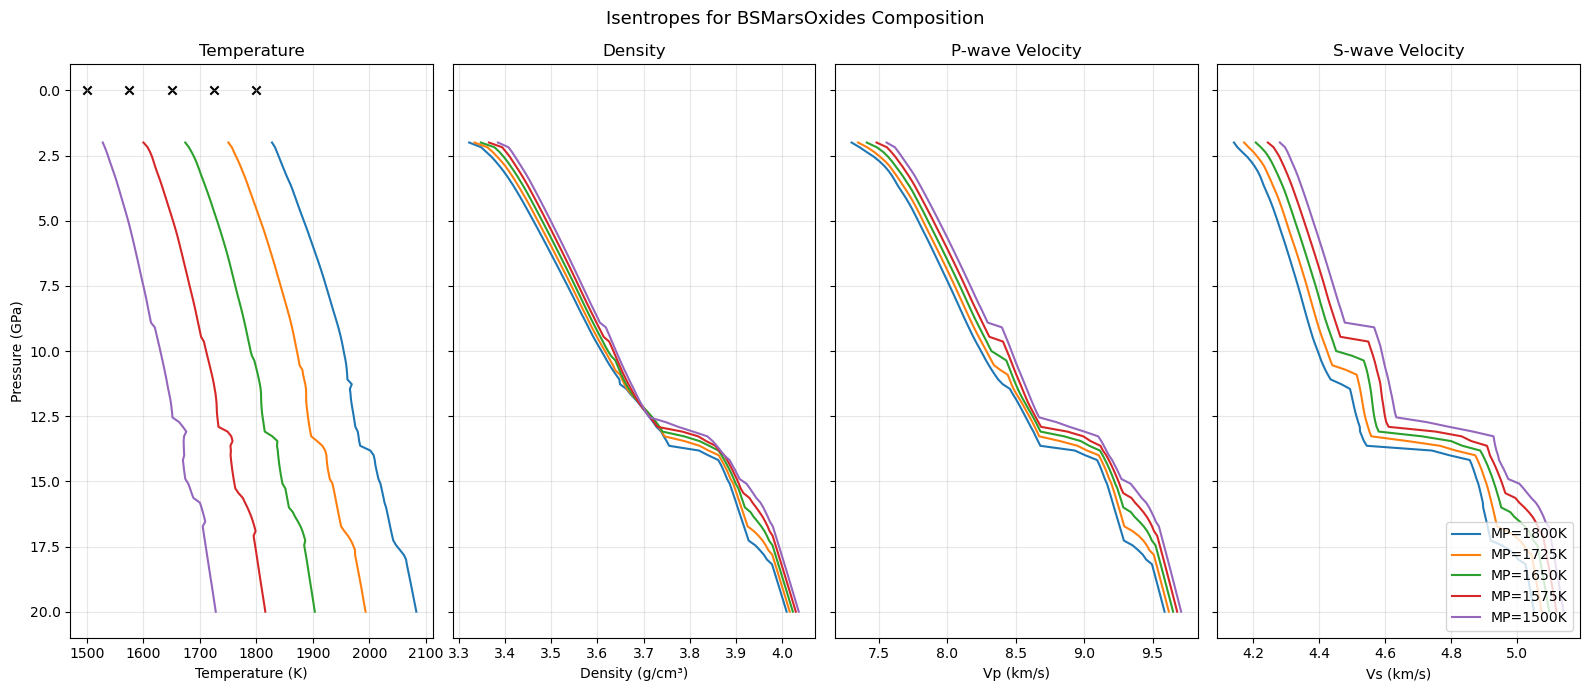

In [3]:
# Get Multiple Isentropes for one composition

BSMarsOxides = { #Yoshizaki and McDonough, 2020
    'SiO2':45.5,
    'Al2O3': 3.59,
    'FeO': 13.0, # Fe Speciation ballparked for Fe3 = 0.1Fetot
    'Fe2O3': 2.1,
    'MgO': 31.0,
    'CaO': 2.88,
    'Na2O':0.59,
    'Cr2O3':0.88
    }

BSEarthOxides = { # McDonough and Sun, 1995
    'SiO2':45.0,
    'Al2O3': 4.45,
    'FeO': 7.75, # Fe Speciation ballparked for Fe3 = 0.03 Fetot
    'Fe2O3': 0.35,
    'MgO': 37.8,
    'CaO': 3.55,
    'Na2O':0.36,
    'Cr2O3':0.38
    }

potential_temperatures = np.linspace(1800, 1500, 5) # K
pressures = np.linspace(2,20,100)

headers = ['P(GPa)(System_main)', 'T(K)(System_main)'] + list(BSMarsOxides.keys())
comp_array = np.array([0,0] + list(BSMarsOxides.values())).reshape(1, -1).astype(np.float32) # Always 2D, even if one row.

# Headers are inteligent: You can do oxides weight percents with both Fe2O3 and FeO, or Elemental mole fraction using Fe3+ or O. 

begin_time = time()
temperature_grid, pressure_grid, adiabat_properties = HeFESToMarsEmulatorCPU.get_isentrope(
        features = comp_array,
        headers = headers,
        pressures = pressures,
        potential_temperatures = potential_temperatures,
        properties = ['S', 'rho', 'Vp', 'Vs', 'Kh']) 

end_time = time()
print(f"Emulator Execution time for {len(potential_temperatures)*len(pressures)} assemblagess: {end_time - begin_time} seconds")

fig, axes = plt.subplots(1, 4, figsize=(16, 7), sharey=True)

prop_configs = [
    (temperature_grid,                        'Temperature (K)',  'Temperature'),
    (adiabat_properties['rho'],           'Density (g/cm³)',  'Density'),
    (adiabat_properties['Vp'],   'Vp (km/s)',        'P-wave Velocity'),
    (adiabat_properties['Vs'],   'Vs (km/s)',        'S-wave Velocity'),
    (adiabat_properties['Kh'],   'Ks (GPa)',        'Isentropic Bulk Modulus')
]

for ax, (data, xlabel, title) in zip(axes, prop_configs):
    if title == 'Temperature':
        ax.scatter(potential_temperatures, np.zeros_like(potential_temperatures), color='k', marker='x')
    for i, mpT in enumerate(potential_temperatures):
        ax.plot(data[i], pressure_grid[i], label=f'MP={mpT:.0f}K')
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Pressure (GPa)')
axes[0].invert_yaxis()
axes[-1].legend(loc='lower right')
fig.suptitle('Isentropes for BSMarsOxides Composition', fontsize=13)
plt.tight_layout()
plt.show()

New model is trained with cold conductive shallow layer: No coverage for shallow (<1.5 GPa) mantle adiabats

Now we try mode 2 of the get_isentropes() function, where we run compositionally independent adiabats in parallel

Emulator Execution time for 500 assemblages: 0.355959415435791 seconds


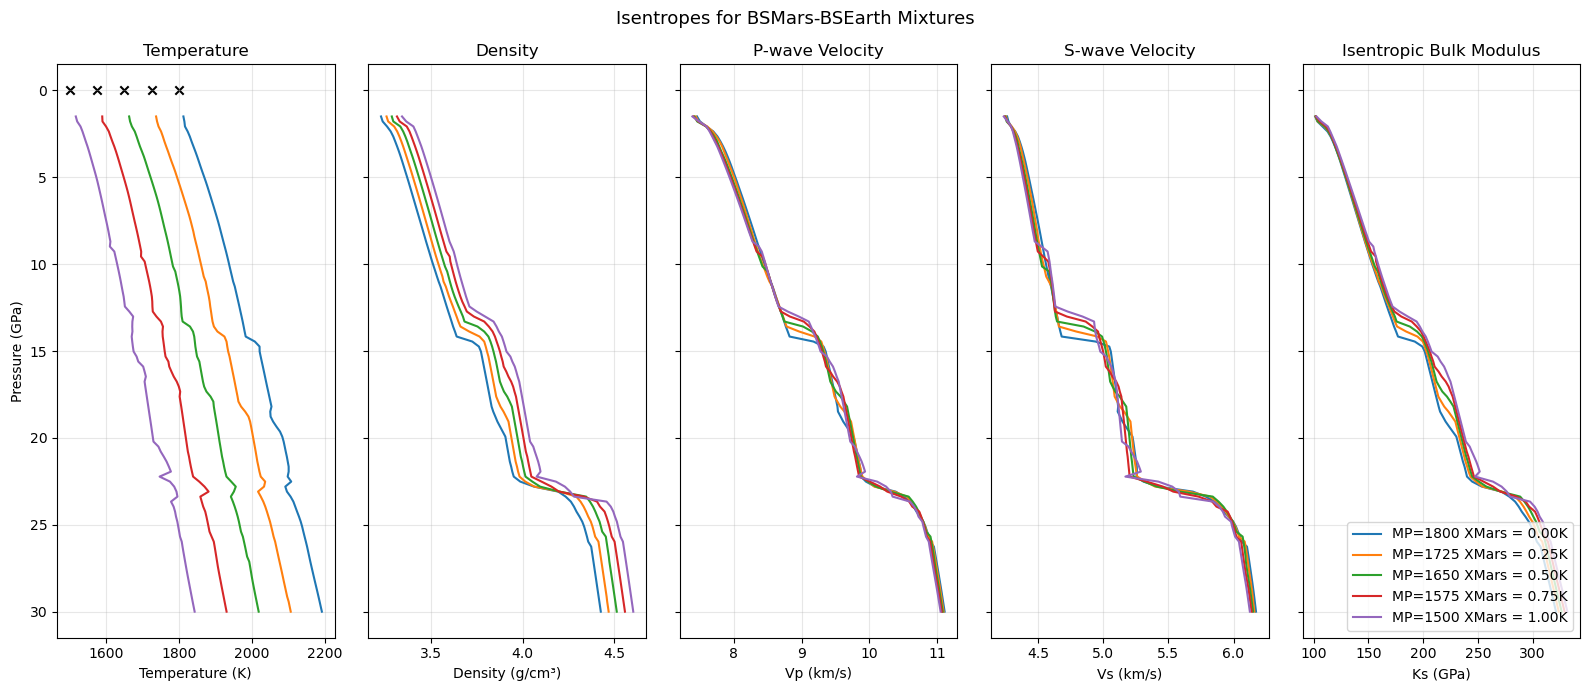

In [6]:


# Get Isentropes in parallel for arbitrary temperature-composition combination


BSMarsOxides = { #Yoshizaki and McDonough, 2020
    'SiO2':45.5,
    'Al2O3': 3.59,
    'FeO': 13.0, # Fe Speciation ballparked for Fe3 = 0.1Fetot
    'Fe2O3': 2.1,
    'MgO': 31.0,
    'CaO': 2.88,
    'Na2O':0.59,
    'Cr2O3':0.88
    }

BSEarthOxides = { # McDonough and Sun, 1995
    'SiO2':45.0,
    'Al2O3': 4.45,
    'FeO': 7.75, # Fe Speciation ballparked for Fe3 = 0.03 Fetot
    'Fe2O3': 0.35,
    'MgO': 37.8,
    'CaO': 3.55,
    'Na2O':0.36,
    'Cr2O3':0.38
    }

potential_temperatures = np.linspace(1800, 1500, 5) # K
pressures = np.linspace(1.5,30,100)

mars_fraction = np.linspace(0, 1, len(potential_temperatures)).tolist() # 0 to 100% BSMarsOxides in 25% increments
#mars_fraction = [1.0, 1.0, 1.0, 1.0, 1.0] # Explicitly define fractions for clarity
headers = ['P(GPa)(System_main)', 'T(K)(System_main)']

# Fancy way to cook up mixes. You could just as well load a .csv with compositions or change a parameter for each composition in a matrix from last loop for MCMC
comp_array = np.zeros((len(potential_temperatures), 2+len(BSEarthOxides)), dtype=np.float32) # Always 2D, even if one row
for i, fraction in enumerate(mars_fraction):
    compositions = mix_compositions([BSEarthOxides, BSMarsOxides],  [1-fraction, fraction])# Mixes Chemical Dictionaries
    if i == 0:
        headers += list(compositions.keys())
    comp_array[i, 2:] = list(compositions.values())

comp_array[:,1] = potential_temperatures

# Headers are inteligent: You can do oxides weight percents with both Fe2O3 and FeO, or Elemental mole fraction using Fe3+ or O. 

begin_time = time()
temperature_grid, pressure_grid, adiabat_properties = HeFESToMarsEmulatorCPU.get_isentrope( # For custom X-T pairs, do not use potentail temperature argument
        features = comp_array,
        headers = headers,
        pressures = pressures,
        properties = ['S', 'rho', 'Vp', 'Vs', 'Kh'])

end_time = time()
print(f"Emulator Execution time for {len(potential_temperatures)*len(pressures)} assemblages: {end_time - begin_time} seconds")

fig, axes = plt.subplots(1, 5, figsize=(16, 7), sharey=True)

prop_configs = [
    (temperature_grid,                        'Temperature (K)',  'Temperature'),
    (adiabat_properties['rho'],           'Density (g/cm³)', 'Density'),
    (adiabat_properties['Vp'],   'Vp (km/s)',        'P-wave Velocity'),
    (adiabat_properties['Vs'],   'Vs (km/s)',        'S-wave Velocity'),
    (adiabat_properties['Kh'],   'Ks (GPa)',        'Isentropic Bulk Modulus')
]

for ax, (data, xlabel, title) in zip(axes, prop_configs):
    if title == 'Temperature':
        ax.scatter(potential_temperatures, np.zeros_like(potential_temperatures), color='k', marker='x')
    for i, mpT in enumerate(potential_temperatures):
        ax.plot(data[i], pressure_grid[i], label=f'MP={mpT:.0f} XMars = {mars_fraction[i]:.2f}K')
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Pressure (GPa)')
axes[0].invert_yaxis()
axes[-1].legend(loc='lower right')
fig.suptitle('Isentropes for BSMars-BSEarth Mixtures', fontsize=13)
plt.tight_layout()
plt.show()


**BJT's version of Ji Ching's workflow:**

Get Adiabatic segment, find T and KS at lithosphere boundary, below is adiabatic and above is conductive. nGibbs does many in parallel. Here 125 pressure profiles are done at once. 4 Random ones are plotted at the bottom.

Step 1: Get T, Ks and grunheisen at random P_lit, S_lit, while ALSO getting the adiabatic segment with isentropic model 

Step 2: Get conduction component using the isothermal model

The majority of the computation time will be in the bulk properties calculations with Burnman. Large batches of these are well-accelerated by the GPU.

Using GPU emulator for parallel isentrope calculations.
Isentropic Emulator: 30998 assemblages in 1.50s


C:\Users\dashf\AppData\Local\Temp\ipykernel_29440\2634566154.py:100: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(output['component_moles'], dtype=torch.float64, device=device),


Fortranslation:  30998 assemblages in 2.45s
Isothermal Emulator: 6502 assemblages in 0.34s


C:\Users\dashf\AppData\Local\Temp\ipykernel_29440\2634566154.py:135: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(iso_output['component_moles'], dtype=torch.float64, device=device),


Fortranslation:  6502 assemblages in 2.35s


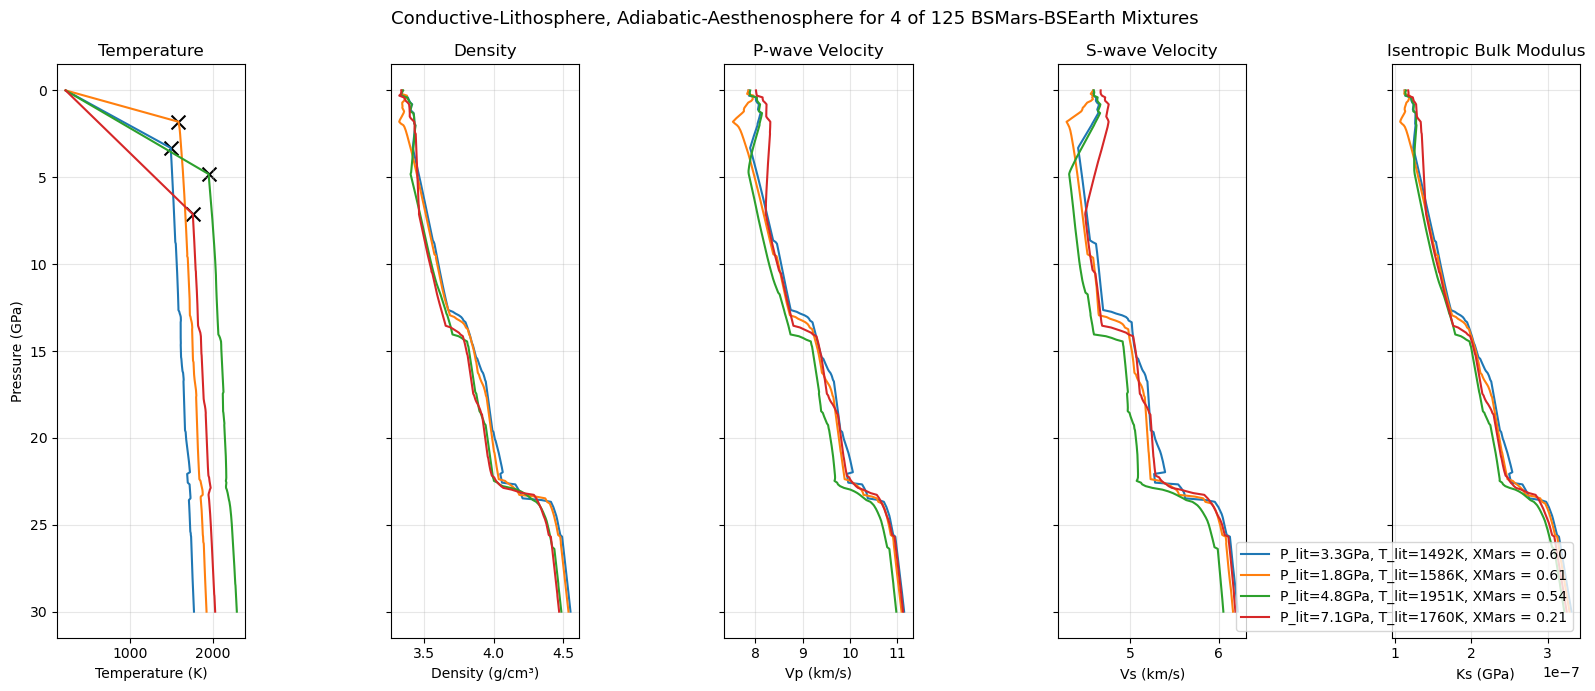

In [7]:
#Let's try randomly chosen entropies and temperatures. We can do ~2**15=32768 assemblages at once, probably ~150 demo PT profiles with 300 discrete pressure samplings 
# First choose trial P_lit and S_lit. Get T_lit from emulator.

use_GPU = True # Set to True to use GPU if available
if torch.cuda.is_available() and use_GPU:
    device = "cuda"
    HeFESToMarsEmulator = HeFESToMarsEmulatorGPU
    print("Using GPU emulator for parallel isentrope calculations.")
else:
    device = "cpu"
    HeFESToMarsEmulator = HeFESToMarsEmulatorCPU
    print("Using CPU emulator for parallel isentrope calculations.")

n_pressures = 300 # pressures per profile
n_profiles = 125 # profiles run in parallel: Trying to keep under 2**15

properties = {} # Initialize 2D property outputs for housekeeping
for prop in  ['temperature', 'S', 'rho', 'Vp', 'Vs', 'Kh']: # Don't need Ks or grunheisen because we are doing the full adiabat calculation.
    properties[prop] = np.zeros((n_profiles, n_pressures), dtype=np.float32)

P_max = 30 # GPa (Mars model not trained beyond 30GPa)
T_min = 220 # The 'surface' temperature for the conduction model. Mars model trained with this value exactly 220
pressures = np.linspace(0,P_max,n_pressures) # Whole transects
P_lit_idx = np.random.choice(np.where((pressures <= 9) & (pressures >= 1.5))[0], size=n_profiles, replace = True) # Get idx of pressure at adiabatic-conductive transition. Can also assign probabilities to get bimodal distribution
P_lit = pressures[P_lit_idx] 
S_lit = np.random.choice(np.linspace(1.75,2.8,n_profiles), size = n_profiles, replace = False)
X_mars = np.random.choice(np.linspace(0,1,n_profiles), size = n_profiles, replace = False) # Could draw random compositions or vary particular mole fractions of certain elements

isentropic_IDX, isothermal_IDX = IDX_2D_Lithosphere(P_lit_idx, n_pressures) # get 2D indexers to populate these preperty arrays and to build the model input grid. Killer helper!

# Build compositions
# Here I am mixing bulk silicate ear and bulk silicate mars just to demonstrate compositional heterogeneity

# Note: You can also use the elemental moles fractions like HeFESTo does, just change the labels/headers to reflect that. 
BSMarsOxides = { #Yoshizaki and McDonough, 2020
    'SiO2':45.5, # Weight percent oxides!
    'Al2O3': 3.59,
    'FeO': 13.0, # Fe Speciation ballparked for Fe3 = 0.1Fetot
    'Fe2O3': 2.1,
    'MgO': 31.0,
    'CaO': 2.88,
    'Na2O':0.59,
    'Cr2O3':0.88
    }

BSEarthOxides = { # McDonough and Sun, 1995
    'SiO2':45.0,
    'Al2O3': 4.45,
    'FeO': 7.75, # Fe Speciation ballparked for Fe3 = 0.03 Fetot
    'Fe2O3': 0.35,
    'MgO': 37.8,
    'CaO': 3.55,
    'Na2O':0.36,
    'Cr2O3':0.38
    }

S_headers = ['P(GPa)(System_main)', 'S(J/g/K)(System_main)']
T_headers = ['P(GPa)(System_main)', 'T(K)(System_main)']

# Build composition input array
comp_array = np.zeros((n_profiles, len(BSEarthOxides)), dtype=np.float32) # Always 2D, even if one row
for i, fraction in enumerate(X_mars):
    compositions = mix_compositions([BSEarthOxides, BSMarsOxides],  [1-fraction, fraction]) # Mixes Chemical Dictionaries, returns another dictionary potentially in different order
    if i == 0:
        S_headers += list(compositions.keys())
        T_headers += list(compositions.keys())
    comp_array[i] = list(compositions.values())


isentropic_input_array = np.zeros((isentropic_IDX[0].shape[0], comp_array.shape[1]+2))
isentropic_input_array[:,2:] = comp_array[isentropic_IDX[0]]
isentropic_input_array[:,1] = S_lit[isentropic_IDX[0]]
isentropic_input_array[:,0] = pressures[isentropic_IDX[1]]


t0 = time()
with torch.no_grad():
    output = HeFESToMarsEmulator.ForwardMB(
        isentropic_input_array, headers=S_headers, outputs=['component_moles', 'temperature']
    )
print(f'Isentropic Emulator: {isentropic_input_array.shape[0]} assemblages in {time() - t0:.2f}s')


T_em = output['temperature'].detach().cpu()
#if hasattr(T_em, 'detach'):
#    T_em = T_em.detach().cpu().numpy()
T_em = np.asarray(T_em, dtype=np.float64).reshape(-1)
properties['temperature'][isentropic_IDX] = T_em

# Build (N, 2) PT in SI units [Pa, K]
PT = np.stack([isentropic_input_array[:,0], T_em], axis=1)

property_names = [prop for prop in properties.keys() if prop.lower() != 'temperature']


# --- Compute HeFESTo properties ---
t1 = time()

Fortranslation_raw = HeFESToMarsEmulator._compute_bulk_EOS_properties(
    torch.tensor(output['component_moles'], dtype=torch.float64, device=device), 
    torch.tensor(PT,              dtype=torch.float64, device=device),
    property_names=property_names,
)
print(f'Fortranslation:  {isentropic_input_array.shape[0]} assemblages in {time() - t1:.2f}s')

for property_name, computed in Fortranslation_raw.items(): # Populate the property matrix with the isentropic outputs
    properties[property_name][isentropic_IDX] = computed

# Isentropic design matrix
# Linear, conductive. This model only goes as low as 1200K. I should probably train colder: I'll ask Paul Lars and Carolina about the low temp bounds if I can't find it in the papers. 
T_conduct = np.empty(0,)
T_lit = []
for i, idx in enumerate(P_lit_idx):
    newT_lit = properties['temperature'][i,idx]
    T_lit.append(newT_lit)
    T_conduct = np.append(T_conduct, np.linspace(T_min, newT_lit, idx+1)[:-1]) #Overshoot by one index to that there is one (and not two) pressures where T = T_lit

properties['temperature'][isothermal_IDX] = T_conduct

isothermal_input_array = np.zeros((isothermal_IDX[0].shape[0], comp_array.shape[1]+2))
isothermal_input_array[:,2:] = comp_array[isothermal_IDX[0]]
isothermal_input_array[:,1] = T_conduct
isothermal_input_array[:,0] = pressures[isothermal_IDX[1]]

t0 = time()
with torch.no_grad():
    iso_output = HeFESToMarsEmulator.ForwardMB(
        isothermal_input_array, headers=T_headers, outputs=['component_moles']
    )
print(f'Isothermal Emulator: {isothermal_input_array.shape[0]} assemblages in {time() - t0:.2f}s')

# --- Compute Fortranslation properties ---
t1 = time()
Fortranslation_raw_isothermal = HeFESToMarsEmulator._compute_bulk_EOS_properties(
    torch.tensor(iso_output['component_moles'], dtype=torch.float64, device=device), 
    torch.tensor(isothermal_input_array[:,:2], dtype=torch.float64, device=device),
    property_names=property_names,
)

for property_name, computed in Fortranslation_raw_isothermal.items(): # Populate the property matrix with the isentropic outputs
    properties[property_name][isothermal_IDX] = computed

print(f'Fortranslation:  {isothermal_input_array.shape[0]} assemblages in {time() - t1:.2f}s')

chosen_plot_rows = np.random.choice(np.arange(n_profiles), size=4, replace=False)

fig, axes = plt.subplots(1, 5, figsize=(16, 7), sharey=True)

prop_configs = [
    (properties['temperature'][chosen_plot_rows],                       'Temperature (K)',  'Temperature'),
    (properties['rho'][chosen_plot_rows],           'Density (g/cm³)', 'Density'),
    (properties['Vp'][chosen_plot_rows],   'Vp (km/s)',        'P-wave Velocity'),
    (properties['Vs'][chosen_plot_rows],   'Vs (km/s)',        'S-wave Velocity'),
    (properties['Kh'][chosen_plot_rows]/1E9,   'Ks (GPa)',        'Isentropic Bulk Modulus')
]

for ax, (data, xlabel, title) in zip(axes, prop_configs):
    for i, idx in enumerate(chosen_plot_rows):
        P_lit_row = P_lit[idx]
        T_lit_row = T_lit[idx]
        x_row = X_mars[idx]
        ax.plot(data[i], pressures, label=f'P_lit={P_lit_row:.1f}GPa, T_lit={T_lit_row:.0f}K, XMars = {x_row:.2f}')
        if title == 'Temperature':
            ax.scatter(T_lit_row, P_lit_row, color='k', marker='x', s=100)
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Pressure (GPa)')
axes[0].invert_yaxis()
axes[-1].legend(loc='lower right')
fig.suptitle(f'Conductive-Lithosphere, Adiabatic-Aesthenosphere for 4 of {n_profiles} BSMars-BSEarth Mixtures', fontsize=13)
plt.tight_layout()
plt.show()




I need to check out the thermal blips at the phase transitions around 23GPa